# Tópico 2 - Aprendizado Supervisionado: Classificação

Nesta aula vamos estudar o uso de algoritmos de **Aprendizado de Máquina Supervisionado**. Focaremos nos algoritmos utilizados para **classificação**, que é a tarefa de predizer classes (rótulos categóricos) para conjuntos de dados (numéricos ou transformados em numéricos).

Existem muitos algoritmos para se realizar essa tarefa, entre eles:
- Regressão Logística
- Análise de Discriminante Linear (LDA)
- Análise de Discriminante Quadrático (QDA)
- Naive Bayes
- k-vizinhos mais próximos (KNN)
- Máquina de Vetor Suporte (SVM)
- Árvore de Decisão
- RandomForest

Cada uma dessas técnicas tem uma forte base matemática e conceitual. Os algoritmos foram propostos ao longo de diversas décadas e possuem diferentes cenários de aplicações

--------------------------

## Exemplo 1 - Entomologia: Gafanhatos vs Esperanças

Foram medidos o comprimento das antenas e do abdômen de dois tipos de insetos: gafanhotos e esperanças.

Trabalhamos com estes dados na aula de Introdução ao Ciência de Dados. Agora iremos aprender a criar um classificador automático para eles:

In [ ]:
# Para trabalhar com dados em tabelas
import pandas as pd

# Para trabalhar com gráficos
import matplotlib.pyplot as plt
import seaborn as sns

### Exemplo 1 - Primeiro passo: carregar os dados e fazer Análise Exploratória

Como já fizemos a Análise Exploratória com esses dados na outras aulas, iremos pular essa etapa.

In [ ]:
dados = pd.read_csv('datasets/dados_topico3/gaf_esp.csv', sep=';')

In [ ]:
dados.head()

### Exemplo 1 - Segundo passo: separar os dados

Precisamos ter claro em nossas mentes quais são os atributos (colunas) preditivas, isto é, aquelas que usaremos para predizer um atributo alvo (coluna alvo). No nosso caso os **atributos preditivos são Comprimento do Abdômen e Comprimento das Antenas**, e o **atributo alvo é a Espécie** que será predita.

Quando se trabalhar com Aprendizado de Máquina Supervisionado, além disso precisamos separar nossos dados em dois conjuntos: um **conjunto de treinamento** e um **conjunto de teste**. Fazemos isso para evitar overfitting do algoritmo.

Existem várias estratégias para se separar dados. Vamos aplicar as principais:

(a) Escolher o tamanho dos conjuntos - 80% para treinamento e 20% para teste;

(b) Selecionar aleatoriamente os dados que irão compor o conjunto de treinamento e teste (usando um seed para garantir reprodutibilidade);

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Escolhendo as colunas preditivas e alvo
x = dados.drop(columns = 'Espécie') # Somente Comprimento do Abdômen e Comprimento das Antenas
y = dados['Espécie']                # Classe alvo

# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.head(5)

In [ ]:
y_train.head(5)

### Exemplo 1 - Terceiro passo: transformar os dados

Dependendo do algoritmo de Aprendizado de Máquina que usamos precisamos modificar os dados para que eles se adequem as premissas do algoritmo.

Existem duas transformações de escalonamento muito utilizadas:

1) **Nomalização** (Normalization) - Também conhecido como escalonamento Min-Max no qual o range de valores da coluna irá fica de 0 (min) até 1 (max);

2) **Padronização** (Standardization) - Modifica a distribuição para que a média seja igual a zero e desvio padrão igual a 1 (o método subtrai a média de todas as entradas e dividide pelo desvio padrão);

Quando escolher uma ou outra? Depende dos seus dados, seu problema e o algoritmo que você quer usar. Em alguns casos, escalonar ou não os dados não irá mudar a solução do problema! Ao longo do cursos iremos estudar alguns casos...

**IMPORTANTE**: independentmente do transformador escolhido, ele deve ser fitado apenas sobre os dados de treinamento. Isto é, o treinamento do escalonador deve receber apenas os dados de treinamento x_train. Após o treinamento do escalonador, ele deverá ser usado para transformar os dados x_test também.


In [ ]:
# Como nossos dados já estão na mesma escala, podemos pular esse passo

### Exemplo 1 - Quarto passo: treinar o algoritmo

Vamos usar o conjunto de treinamento para treinar o algoritmo escolhido.

Existem vários algoritmos possíveis. Cada algoritmo tem seus **hiperparâmetros** (parâmetros que devem ser escolhidos para melhorar a performance do algoritmo). Para entender os hiperparâmetros de cada algoritmo é necessário entender a fundo como aquele algoritmo funciona. Ao longo das próximas aulas estaremos estudando como esses algoritmos funcionam.

Aqui vamos usar um dos algoritmos mais simples existentes, o Descriminador Linear:

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

lda.fit(x_train,y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

Pronto! Nosso algoritmo de ML está pronto para ser usado. A partir de agora ele consegue classificar qualquer nova entrada entre as duas classes.
Chamamos de inferência a etapa de predizer classes quando o algoritmo já está treinado. Vejamos:

In [ ]:
nova_entrada = [[4,2]] # Uma lista de novas entradas, sendo de apenas um inseto

In [ ]:
lda.predict(nova_entrada)

<font color='red'>Entretanto, como sabemos se o algoritmo está bom?</font>

### Exemplo 1 - Quinto passo: testar e avaliar

Usaremos o conjunto de teste para testar o classificador criado e treinando no passo anterior.

Uma vez que realizamos um teste, precisamos avaliar o desempenho do nosso método. Diferentes hiperparâmetros e diferentes algoritmos podem ter um desempenho diferente. Apesar de sempre buscarmos o melhor desempenho, devemos levar em consideração outros aspectos para decidir o que é um desempenho aceitável. A primeira coisa a definir são as **métricas de desempenho** que podem ser comparadas entre diferentes algoritmos.

Existem várias métricas para se medir o **desempenho de um classificador**: métricas de performance, métricas de tempo consumido, métricas de memória consumida, etc. Vamos focar em uma métrica de performance muito utilizada no dia a dia de trabalho: a **Matriz de Confusão** e seus índices (**Acurácia, Precisão, Recall e F1-score**).

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, plot_confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
# Perceba que estamos passando apenas o x de teste, afinal o algoritmo é que nos dira qual é o y
y_predicoes = lda.predict(x_test)

In [ ]:
y_predicoes

In [ ]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=['Gafanhoto','Esperança'])

In [ ]:
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=['Gafanhoto','Esperança'])
disp.plot(values_format='d')

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

Vamos desenhar sobre um gráfico de dispersão o modelo matemático encontrado pelo algoritmo de Classificação LDA. Perceba que o classificador LDA é um algoritmo paramétrico:

In [ ]:
import numpy as np

# São os coeficientes do nosso modelo de ML treinado
c1, c2 = lda.coef_[0]
b = lda.intercept_

# É a equação da reta do LDA
x1 = np.arange(0,10)
x2 = - (c1/c2)* x1 - b/c2

A fronteira de decisão entre as classes em um classificador LDA é uma linha.

Toda linha tem uma função metamática associada.

Podemos ver os coeficientes dessa fronteira (hiperplano ou linhas) na propriedade `coef_`.

Para um problema de duas dimensões, (como o acima), temos dois coeficientes. Vamos chamar esses coeficientes de $c_1$ e $c_2$, e os atributos de $x_1$ e $x_2$, e o valor de interceptação no eixo das ordenadas de $b$. Dessa maneira, temos a equação da fronteira:  

$$ c_1 x_1 + c_2 x_2  + b = 0  $$

Agora, resolvedo para $x_2$, podemos obter a equação da reta:

$$ x_2 =  -\frac{c_1}{c_2}x_1 - \frac{b}{c_2} $$

In [ ]:
plot = sns.jointplot(data=dados, x="Comprimento do Abdômen", y="Comprimento das Antenas", hue = 'Espécie',
              height=5, ratio=2, marginal_ticks=True
             )
plot.ax_joint.plot(x1, x2, 'r-', linewidth = 2)
plot.ax_marg_x.axvline(x=4.5, color='k', linestyle='--') # Somente indicativo
plot.ax_marg_y.axhline(y=5.3, color='k', linestyle='--') # Somente indicativo
plot.ax_joint.set_xlim(0,11)
plot.ax_joint.set_ylim(0,11)

### Exemplo 1 - Sexto passo: Produção

Se nosso algoritmo está bom e atende os requisitos de negócio, podemos colocar ele em produção. Essa etapa envolve conhecimento do tipo de dispositivo em que iremos rodar a solução.

Por exemplo, iremos colocar esse modelo em um site? Precisamos trabalhar com o pessoal de backend.
Vamos embarcar em um veículo autônomo? Time de engenharia de software e engenharia eletrônica.

Esse passo inteiro transcede o escopo da nossa disciplina, já que envolve outras disciplinas e competências.

Vamos contudo ver como "baixar" nosso modelo pronto para não precisar treina-lo novamente. Afinal, iremos empregar o algoritmo já treinado e pronto para uso em produção (a menos que estejamos usando técnicas mais sofisticadas de machine learning como Active Learning e Atualização de Modelo em Execução).

A etapa de "salvar/baixar" o modelo pronto é chamada de **Persistência do Modelo**.  Quando usamos um modelo pronto, é comum dizer que estamos usando um **modelo pré-treinado**.

In [ ]:
import pickle

Pickle é um formato de arquivo de objeto python serializado na memória permanente. Ele é análogo ao JSON para dicionários ou o CSV para tabelas, mas ele funciona para objetos python, ou seja, é muito mais abrangente!

In [ ]:
# vamos salvar em bytes (flag wb) para ser mais cross-platform (acessível a vários sistemas)
with open('meu_modelo_serializado.pickle', 'wb') as f:
    pickle.dump(lda, f)

Pronto! Nosso modelo está salvo. Se quisermos usá-lo em um código em Python, podemos simplesmente carregá-lo:

In [ ]:
with open('meu_modelo_serializado.pickle', 'rb') as f:
    modelo_carregado = pickle.load(f)

In [ ]:
modelo_carregado.predict([[1,2]])

Além do Pickle, o Scikit-Learn tem o método joblib que é mais eficiente para serializar modelos treinados através dessa biblioteca. Vejamos como usar esse formato de arquivo:

In [ ]:
from joblib import dump, load

In [ ]:
dump(lda, 'meu_modelo_serializado.joblib')

In [ ]:
modelo_carregado2 = load('meu_modelo_serializado.joblib')

In [ ]:
modelo_carregado2.predict([[1,2]])

-----------------------------------------------
## Exemplo 2 - Botânica: Íris Dataset

Esse dataset contém medidas da largura e comprimento da pétala e da sépala de **150 amostras** de flores, assim como a espécie de cada uma (*versicolor*, *setosa*, *virginica*). Mais informações: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html.

<img src="https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png" alt="dieta" width="600px">

### Exemplo 2 - Primeiro passo: Análise Exploratória

In [ ]:
from sklearn import datasets # Para carregar dataset pronto no scikit-learn
import pandas as pd # Para trabalhar com dados em tabelas

# Para trabalhar com gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carregando os dados
# Estamos carregando os dados do próprio scikitlearn
iris = datasets.load_iris()

dados = pd.DataFrame(data=iris.data,  # Estamos dizendo que o dados do dataframe são o atributo data do objeto iris
                     columns = iris.feature_names) # Já o nome das colunas do dataframe serão o atrib feature_names

In [ ]:
dados.info()

In [ ]:
# Aqui estamos criando uma funcao que recebe o número da classe e retorna o nome correspondente
def mapear_nomes(numero_classe):
    return(iris.target_names[numero_classe])

In [ ]:
dados['flower'] = iris.target
dados['flower_name'] = dados['flower'].apply(mapear_nomes)

In [ ]:
dados.head()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), dpi=80)

sns.histplot(ax=axes[0][0],
            data=dados,  # Perceba que estamos passando a coluna o dataframe completo
            x = dados['sepal length (cm)'], # E aqui estamos selecionando a coluna
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name'],
            palette=["g", "r", "b"]
            )

sns.histplot(ax=axes[0][1],
            data=dados,
            palette=["g", "r", "b"],
            x = dados['sepal width (cm)'],
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name']
            )

sns.histplot(ax=axes[1][0],
            data=dados,  # Perceba que estamos passando a coluna o dataframe completo
            x = dados['petal length (cm)'], # E aqui estamos selecionando a coluna
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name'],
            palette=["g", "r", "b"]
            )

sns.histplot(ax=axes[1][1],
            data=dados,
            palette=["g", "r", "b"],
            x = dados['petal width (cm)'],
            kde=True,
            bins=20,
            linewidth=0.7,
            hue = dados['flower_name']
            )

plt.subplots_adjust(wspace=0.2, hspace=0.4)

### Exemplo 2 - Segundo passo: separar os dados

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Escolhendo as colunas preditivas e alvo
x = dados.drop(columns = ['flower', 'flower_name']) # Tudo menos flower e flower_name (classes alvo)
y = dados['flower_name'] # Classe alvo

# Dividindo conjunto de treinamento e conjunto de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 8, stratify=y)
# O stratify mantem a mesma proporção de exemplos para cada classe

### Exemplo 2 - Terceiro passo: transformar os dados

Para mais informações sobre tipos de escalonamento, consulte:
https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
# Instanciando o Escalonador
#scaler = StandardScaler()
scaler = MinMaxScaler()

# Treinando o escalonador
scaler.fit(x_train)

# Usando o escalonador treinado para transformar os dados
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Exemplo 2 - Quarto passo: treinar o algoritmo

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()  # Criamos o objeto do classificador (não mudamos nenhum hiperpârametro)

knn.fit(x_train_scaled, y_train) # Treinamos o classificador passando apenas o conjunto de dados de treinamento

### Exemplo 2 - Quinto passo: testar e avaliar

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, plot_confusion_matrix,classification_report
from sklearn.metrics import cohen_kappa_score, roc_auc_score, roc_curve

In [ ]:
# Perceba que estamos passando apenas o x de teste, afinal o algoritmo é que nos dira qual é o y
y_predicoes = knn.predict(x_test_scaled)

In [ ]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=iris.target_names)

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=iris.target_names)
disp.plot(values_format='d')

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Métrica do Coeficiente Kappa de Cohen
cohen_kappa_score(y_test, y_predicoes)

### Exemplo 2 - Retornando ao quarto passo para fazer o ajuste de hiperparâmetros

Dessa vez, não iremos apenas usar o algoritmo KNN, iremos ajustar os hiperpametros para encontrar aqueles que performam melhor para a tarefa.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

Vamos observar o que acontece com o erro conforme aumentamos o número de vizinhos:

In [ ]:
error = []

# Calculating error for K values between 1 and 40
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_scaled, y_train)
    pred_i = knn.predict(x_test_scaled)
    error.append(np.mean(pred_i != y_test))

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [ ]:
# Buscar os melhores parâmetros
# Vamos usar uma técnica chamada Gridsearch que é basicamente a busca por força bruta
# Iremos utilizar a técnica de validação cruzada de 5 folds (divisões) em cima do conjunto de treinamento
# Como métrica de melhor desemepnho usaremos a acurácia, isto é,
# estamos buscando os hiperparâmetros que maximizam a acurácia

# Parâmetros testados
param_grid = {'n_neighbors':[3,5,11,19,25],
              'weights': ['uniform', 'distance'],
              'metric':['cosine', 'euclidean', 'manhattan']
             }

# Métrica de desempenho = melhor acurácia
gs_metric = make_scorer(accuracy_score, greater_is_better=True)

grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, scoring=gs_metric, cv=5, n_jobs=6, verbose=3)
grid.fit(x_train_scaled, y_train)
knn_params = grid.best_params_
print('KNN', knn_params)

### Fazendo os passos 4 e 5 com os melhores valores de hiperparâmetros

In [ ]:
# Criamos o objeto do classificador usando os hiperparâmetros encontrados
knn = KNeighborsClassifier(metric = 'euclidean',
                          n_neighbors = 5, # Perceba que quando olhamos o k variando, k=6 deu melhor
                          weights = 'uniform')

# Treinamos o classificador passando apenas o conjunto de dados de treinamento
knn.fit(x_train_scaled, y_train)

# Fazendo as predições
y_predicoes = knn.predict(x_test_scaled)

In [ ]:
matriz_confusao = confusion_matrix(y_true = y_test,
                                   y_pred = y_predicoes,
                                   labels=iris.target_names)

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))
disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=iris.target_names)
disp.plot(values_format='d')

In [ ]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(y_test, y_predicoes))

In [ ]:
# Métrica do Coeficiente Kappa de Cohen
cohen_kappa_score(y_test, y_predicoes)

------------------
## <font color='red'> Atenção</fonte>:

A seguir são apresentados dois datasets de pessoas reais.

Ao se trabalhar com dados de pessoas devemos considerar a origem e os preceitos **bioéticos** envolvidos em sua coleta, construção e utilização.

Além disso, é boa prática que os dados estejam anonimizados.

----------------------
## Exercício 1 - Diagnóstico médico: Problemas Ortopédicos na Coluna Vertebral

Esse dataset contém dados sobre problemas ortopédicos na coluna vertebral, diagnosticados no Centre Médico-Chirurgical de Réadaptation des Massues, em Lyon, France. Contém 6 atributos biomecânicos para 310 entradas anonimizadas, sendo 100 de pacientes considerados sem problemas (Normal - NO), 60 de pacientes com Hérnia de Disco (Disk Hernia - DH) e 150 de pacientes com Espondilolistese (Spondylolisthesis - SL).

O dataset está disponível em https://www.openml.org/d/1523


![image-8.png](attachment:image-8.png)

### Exercício 1 - Primeiro passo: Carregar dados e Realizar a Análise Exploratória

Para importar dados do OpenML podemos usar uma função pronta na biblioteca do Scikit-Learn:

In [1]:
from sklearn.datasets import fetch_openml

In [2]:
dados = fetch_openml(data_id=1523)

Perceba que o tipo do dado continua sendo um objeto Bunch, como vimos na aula 15.

In [3]:
type(dados)

sklearn.utils._bunch.Bunch

In [4]:
dados

{'data':             V1         V2         V3         V4          V5         V6
 0    63.027818  22.552586  39.609117  40.475232   98.672917  -0.254400
 1    39.056951  10.060991  25.015378  28.995960  114.405425   4.564259
 2    68.832021  22.218482  50.092194  46.613539  105.985136  -3.530317
 3    69.297008  24.652878  44.311238  44.644130  101.868495  11.211523
 4    49.712859   9.652075  28.317406  40.060784  108.168725   7.918501
 ..         ...        ...        ...        ...         ...        ...
 305  47.903565  13.616688  36.000000  34.286877  117.449062  -4.245395
 306  53.936748  20.721496  29.220534  33.215251  114.365845  -0.421010
 307  61.446597  22.694968  46.170347  38.751628  125.670725  -2.707880
 308  45.252792   8.693157  41.583126  36.559635  118.545842   0.214750
 309  33.841641   5.073991  36.641233  28.767649  123.945244  -0.199249
 
 [310 rows x 6 columns],
 'target': 0      1
 1      1
 2      1
 3      1
 4      1
       ..
 305    2
 306    2
 307    2
 

Agora que temos os dados carregamos em memória, podemos transformá-lo em um Dataframe do pandas:

In [5]:
import pandas as pd

In [6]:
df = pd.DataFrame(dados.data,columns=dados.feature_names)

In [7]:
df.head()

,V1,V2,V3,V4,V5,V6
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501


Vamos adicionar a coluna de target na frente.

Perceba, entretanto, que o atributo target_names do Bunch dados não nos é útil. Vamos precisar encontrar o diagnóstico representado por cada número de outra forma. Por sorte, temos a informação de quantas entradas são para cada classe e podemos usar isso para mapear os nomes corretos:

In [8]:
dados.target_names

['Class']

In [9]:
list(dados.target).count('1')

60

In [10]:
list(dados.target).count('2')

100

In [11]:
list(dados.target).count('3')

150

In [12]:
target_map={
    '1':'Disk Hernia',
    '2':'Normal',
    '3':'Spondylolisthesis'
}

In [13]:
df['diagnostic'] = [target_map[target] for target in dados.target]

In [15]:
df.head(10)

,V1,V2,V3,V4,V5,V6,diagnostic
0,63.027818,22.552586,39.609117,40.475232,98.672917,-0.254400,Disk Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Disk Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985136,-3.530317,Disk Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Disk Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Disk Hernia
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Disk Hernia
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Disk Hernia
7,45.366754,10.755611,29.038349,34.611142,117.270068,-10.675871,Disk Hernia
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Disk Hernia
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Disk Hernia


Vamos gerar algumas estatísticas e visualizações exploratórias dos dados:

In [16]:
import seaborn as sns

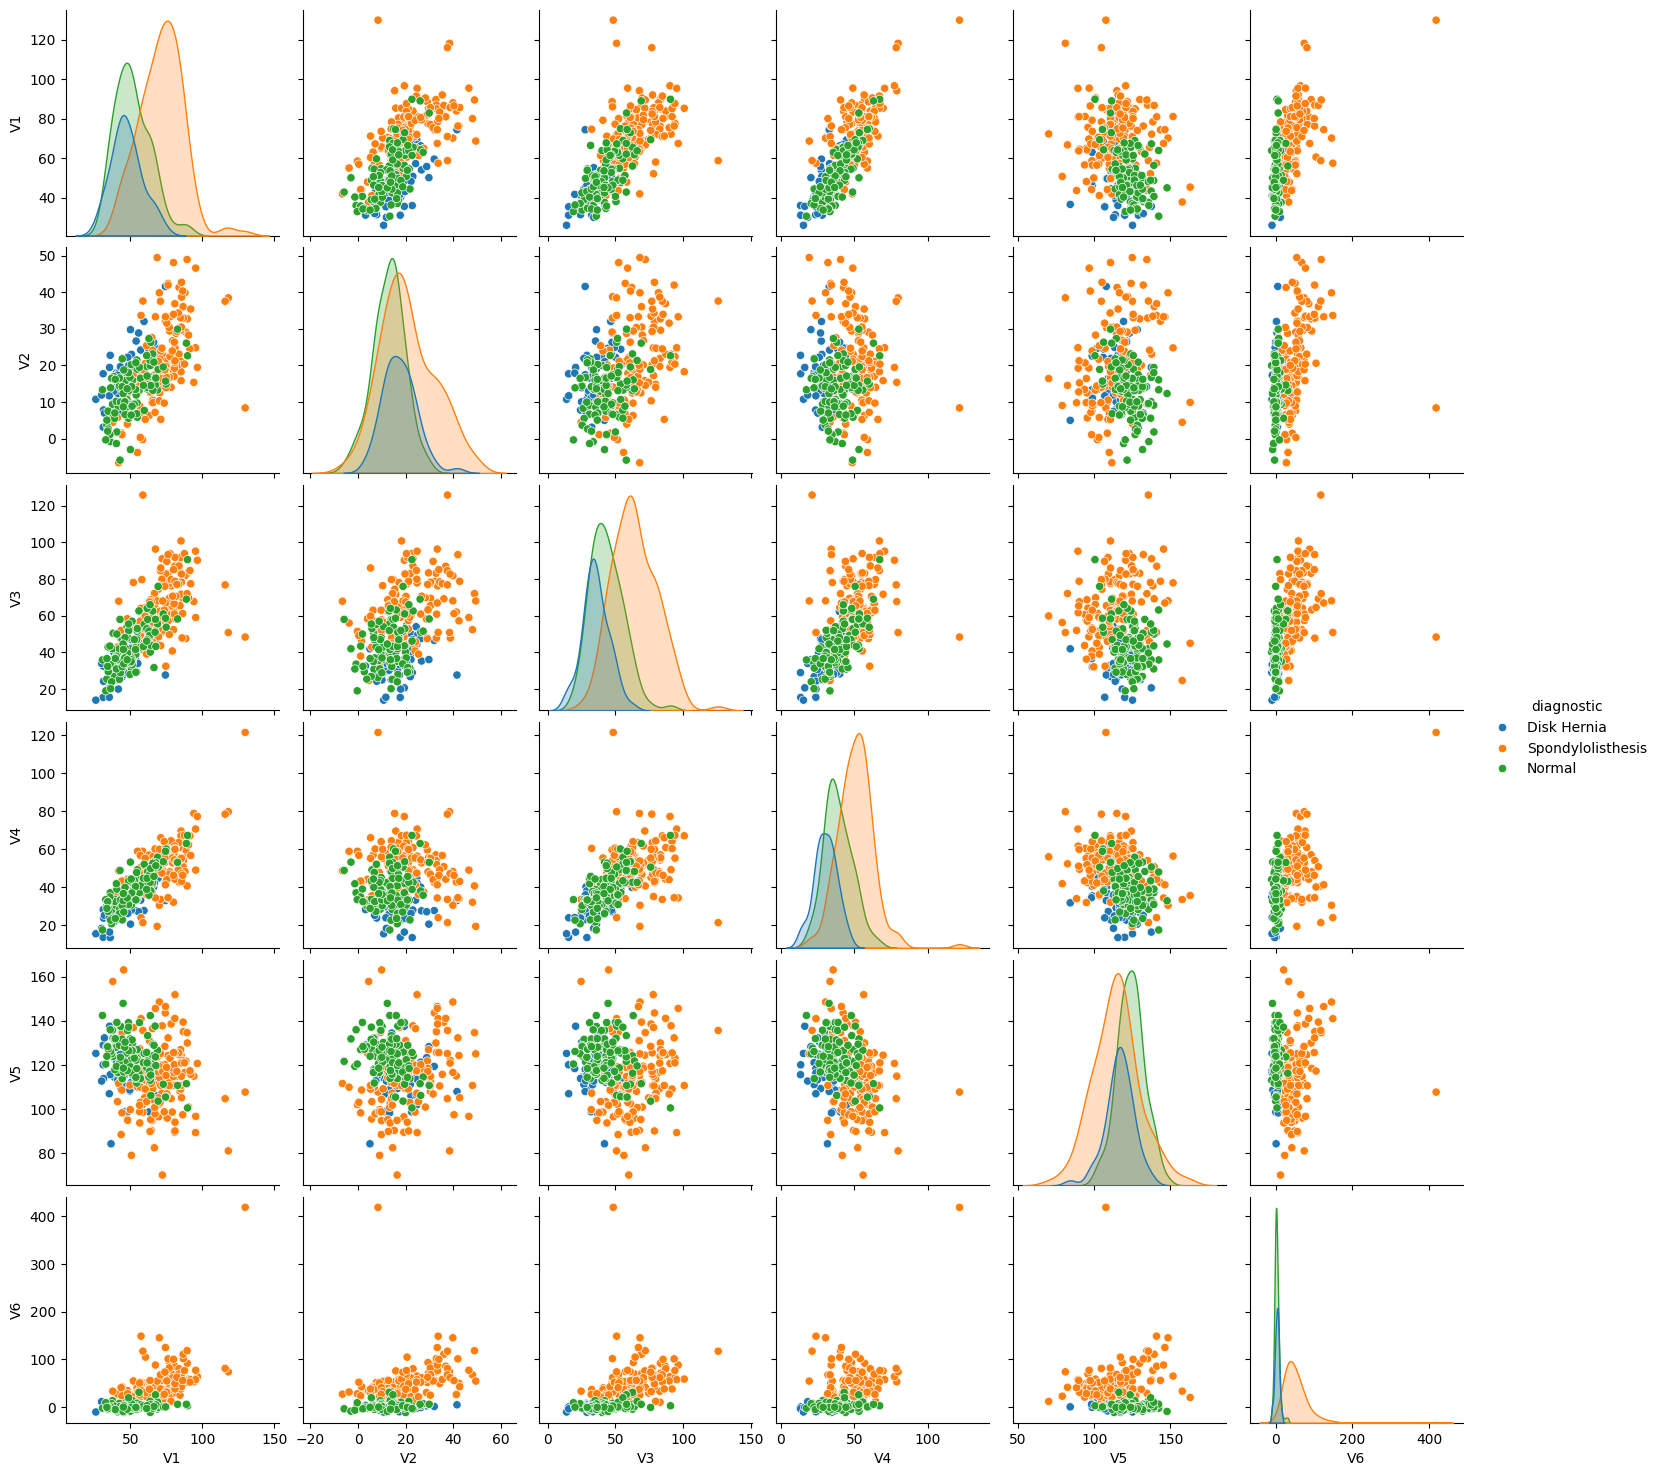

In [17]:
sns.pairplot(df, hue='diagnostic')

In [18]:
df.groupby('diagnostic').mean()

,V1,V2,V3,V4,V5,V6
diagnostic,,,,,,
Disk Hernia,47.638407,17.398795,35.463524,30.239612,116.474968,2.480251
Normal,51.685244,12.821414,43.542605,38.863830,123.890834,2.186572
Spondylolisthesis,71.514224,20.748038,64.110108,50.766186,114.518810,51.896687


In [19]:
df.groupby('diagnostic').std()

,V1,V2,V3,V4,V5,V6
diagnostic,,,,,,
Disk Hernia,10.697131,7.016708,9.767795,7.555388,9.355720,5.531177
Normal,12.368161,6.778503,12.361388,9.624004,9.014246,6.307483
Spondylolisthesis,15.109337,11.506169,16.397068,12.318813,15.579995,40.108030


### agora é com você ...

Faça um classificador que prediz qual é o tipo de doença baseado nos biomarcadores levantados.

In [21]:
from sklearn.model_selection import train_test_split

In [28]:
# Passo 2 - Separacao de dados

# Separando colunas
x = df[['V1','V2','V3','V4','V5', 'V6']]
y = df['diagnostic']

# Separar linhas
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=42, stratify=y)

In [44]:
# Passo 2.5 - Transformação dos dados (escalonamento)

from sklearn.preprocessing import MinMaxScaler

escalonador = MinMaxScaler()

escalonador.fit(x_train)

x_train_escalonados = escalonador.transform(x_train)
x_test_escalonados = escalonador.transform(x_test)

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [45]:
# Passo 3   -Treinamento dos Algoritmos
knn = KNeighborsClassifier()
knn.fit(x_train_escalonados, y_train)

dt = DecisionTreeClassifier(random_state=10)
dt.fit(x_train,y_train)

rf = RandomForestClassifier(random_state=10)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=10)

In [46]:
from sklearn.metrics import classification_report

In [47]:
# Passo 4 - Teste
y_pred = knn.predict(x_test_escalonados)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

      Disk Hernia       0.58      0.58      0.58        12
           Normal       0.61      0.85      0.71        20
Spondylolisthesis       0.95      0.70      0.81        30

         accuracy                           0.73        62
        macro avg       0.72      0.71      0.70        62
     weighted avg       0.77      0.73      0.73        62



In [38]:
y_pred_dt = dt.predict(x_test)

print(classification_report(y_test, y_pred_dt))

                   precision    recall  f1-score   support

      Disk Hernia       0.41      0.58      0.48        12
           Normal       0.62      0.40      0.48        20
Spondylolisthesis       0.91      0.97      0.94        30

         accuracy                           0.71        62
        macro avg       0.64      0.65      0.63        62
     weighted avg       0.72      0.71      0.70        62



In [39]:
y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

                   precision    recall  f1-score   support

      Disk Hernia       0.69      0.75      0.72        12
           Normal       0.82      0.70      0.76        20
Spondylolisthesis       0.91      0.97      0.94        30

         accuracy                           0.84        62
        macro avg       0.81      0.81      0.80        62
     weighted avg       0.84      0.84      0.84        62



In [ ]:
# Separar os dados
# Treinar o algoritmo
# Testar as predições

----------------------
## Exercício 2 - Diagnóstico médico: Diabetes no povo Pima

Esse dataset contém dados sobre incidência de diabetes em mulheres do Povo Pima (índios nativos norte americanos originários do atual Estado do Arizona). Contém 8 atributos biomédicos para 768 entradas anonimizadas, sendo 500 testados negativo para diabetes e 268 testados positivo para diabetes.

O dataset está disponível em https://www.openml.org/d/37.

![image-6.png](attachment:image-6.png)

São 8 atributos mais a classe (onde 1 significa que testou positivo para diabetes):
- **preg** Number of times pregnant
- **plas** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **pres** Diastolic blood pressure (mm Hg)
- **skin** Triceps skin fold thickness (mm)
- **insu** 2-Hour serum insulin (mu U/mL)
- **mass** Body mass index (weight in kg/ height in m²)
- **pedi** Diabetes pedigree function
- **age** Age (years)
- **Class** variable (0 or 1)

### Exercício 2.1: Faça análise exploratória dos dados

In [ ]:
## Coloque seu código aqui

### Exercício 2.2: Crie um classificador que prediz se uma determinada mulher tem ou não um diagnostico positivo para diabetes. Qual foi o melhor modelo (em acurácia) que você conseguiur criar?

In [ ]:
## Coloque seu código aqui

In [ ]:
# Bibliotecas
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Carregar o dataset ARFF
data, meta = arff.loadarff('/mnt/data/dataset_37_diabetes.arff')
df = pd.DataFrame(data)

# Converter atributos byte para string (se necessário)
df['class'] = df['class'].str.decode('utf-8')

# Verificar dados
print("Amostras do dataset:")
print(df.head())

# Separar features e rótulos
X = df.drop('class', axis=1)
y = df['class']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinar modelo
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Avaliar desempenho
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
